In [5]:
import pandas as pd

columns = ['Overall Qual', 'Overall Cond', 'Gr Liv Area',
           'Central Air', 'Total Bsmt SF', 'SalePrice']
df = pd.read_csv('AmesHousing.txt', sep='\t', usecols=columns)
df.head()

,Overall Qual,Overall Cond,Total Bsmt SF,Central Air,Gr Liv Area,SalePrice
0,6,5,1080.0,Y,1656,215000
1,5,6,882.0,Y,896,105000
2,6,6,1329.0,Y,1329,172000
3,7,5,2110.0,Y,2110,244000
4,5,5,928.0,Y,1629,189900


In [6]:
df.shape

(2930, 6)

In [7]:
df['Central Air'] = df['Central Air'].map({'N': 0, 'Y': 1})

In [8]:
df.isnull().sum()

Overall Qual     0
Overall Cond     0
Total Bsmt SF    1
Central Air      0
Gr Liv Area      0
SalePrice        0
dtype: int64

In [9]:
df = df.dropna(axis=0)
df.isnull().sum()

Overall Qual     0
Overall Cond     0
Total Bsmt SF    0
Central Air      0
Gr Liv Area      0
SalePrice        0
dtype: int64

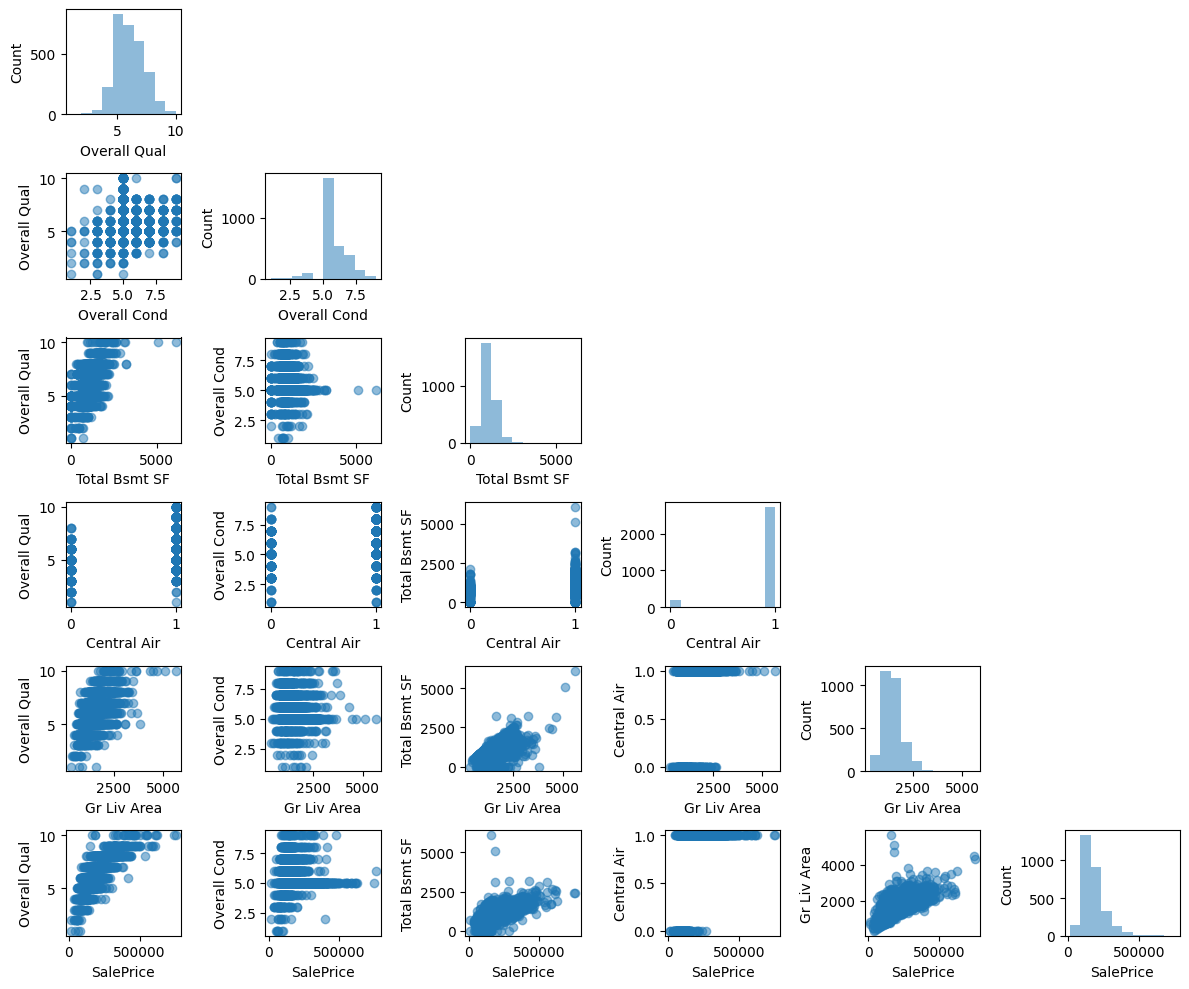

In [10]:
import matplotlib.pyplot as plt
from mlxtend.plotting import scatterplotmatrix

scatterplotmatrix(df.values, figsize=(12, 10),
                  names=df.columns, alpha=.5)
plt.tight_layout()
plt.show()

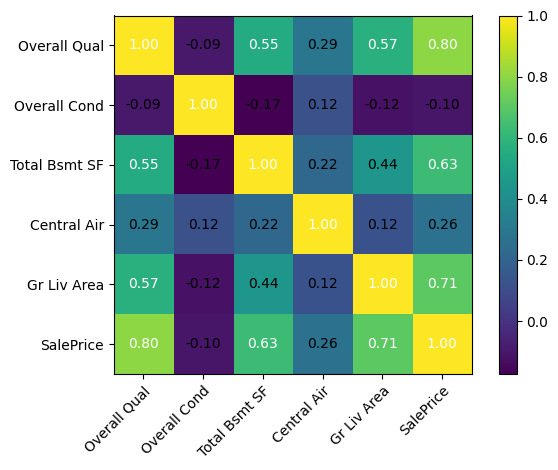

In [11]:
import numpy as np
from mlxtend.plotting import heatmap

cm = np.corrcoef(df.values.T)
hm = heatmap(cm, row_names=df.columns, column_names=df.columns)
plt.tight_layout()
plt.show()

In [12]:
class LinearRegressionGD:
    def __init__(self, eta=0.01, n_iter=50, random_state=1):
        self.eta = eta
        self.n_iter = n_iter
        self.random_state = random_state

    def fit(self, X, y):
        rgen = np.random.RandomState(self.random_state)
        self.w_ = rgen.normal(loc=0., scale=.01, size=X.shape[1])
        self.b_ = np.array([0.])
        self.losses_ = []

        for i in range(self.n_iter):
            output = self.net_input(X)
            errors = y - output
            self.w_ += self.eta * 2. * X.T.dot(errors) / X.shape[0]
            self.b_ += self.eta * 2. * errors.mean()
            loss = (errors ** 2).mean()
            self.losses_.append(loss)

    def net_input(self, X):
        return np.dot(X, self.w_) + self.b_

    def predict(self, X):
        return self.net_input(X)

In [13]:
X = df[['Gr Liv Area']].values
y = df['SalePrice'].values
from sklearn.preprocessing import StandardScaler
sc_x = StandardScaler()
sc_y = StandardScaler()
X_std = sc_x.fit_transform(X)
y_std = sc_y.fit_transform(y[:, np.newaxis]).flatten()
lr = LinearRegressionGD(eta=0.1)
lr.fit(X_std, y_std)


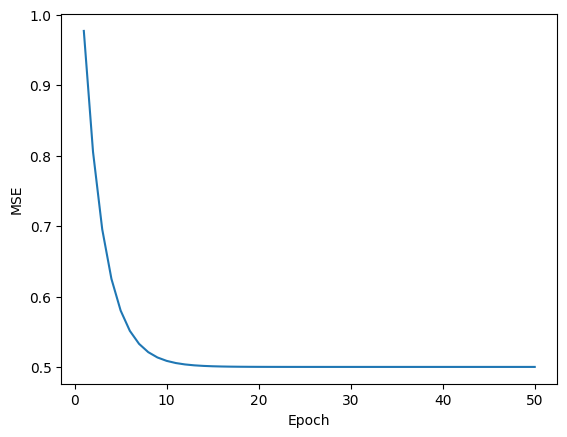

In [14]:
plt.plot(range(1, lr.n_iter + 1), lr.losses_)
plt.ylabel('MSE')
plt.xlabel('Epoch')
plt.show()

In [22]:
def lin_regplot(X, y, model):
    plt.scatter(X, y, c='red', edgecolor='white', s=40)
    plt.plot(X, model.predict(X), color='green', lw=2)

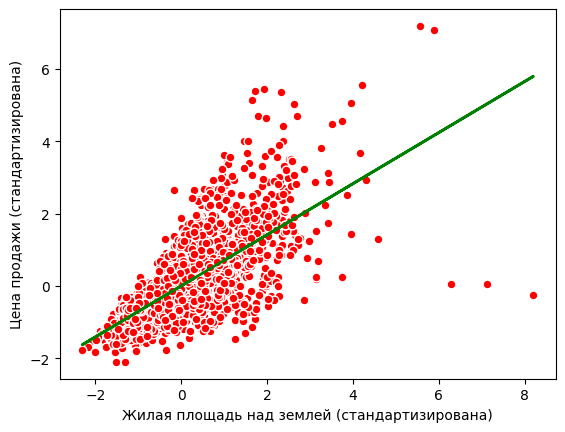

In [23]:
lin_regplot(X_std, y_std, lr)
plt.xlabel('Жилая площадь над землей (стандартизирована)')
plt.ylabel('Цена продажи (стандартизирована)')
plt.show()

In [25]:
feature_std = sc_x.transform(np.array([[2500]]))
target_std = lr.predict(feature_std)
target_reverted = sc_y.inverse_transform(target_std.reshape(-1, 1))
print(f'Sales price: ${target_reverted.flatten()[0]:.2f}')

Sales price: $292507.07


In [28]:
from sklearn.linear_model import LinearRegression
slr = LinearRegression()
slr.fit(X, y)
y_pred = slr.predict(X)
print(f'Наклон: {slr.coef_[0]:.3f}')
print(f'Пересечение: {slr.intercept_:.3f} ')

Наклон: 111.666
Пересечение: 13342.979 


In [29]:
from sklearn.linear_model import RANSACRegressor
ransac = RANSACRegressor(LinearRegression(),
                         max_trials=100, min_samples=.95,
                         residual_threshold=None, random_state=123)
ransac.fit(X, y)

,"estimator estimator: object, default=NoneBase estimator object which implements the following methods:* `fit(X, y)`: Fit model to given training data and target values.* `score(X, y)`: Returns the mean accuracy on the given test data, which is used for the stop criterion defined by `stop_score`. Additionally, the score is used to decide which of two equally large consensus sets is chosen as the better one.* `predict(X)`: Returns predicted values using the linear model, which is used to compute residual error using loss function.If `estimator` is None, then:class:`~sklearn.linear_model.LinearRegression` is used fortarget values of dtype float.Note that the current implementation only supports regressionestimators.",LinearRegression()
,"min_samples min_samples: int (>= 1) or float ([0, 1]), default=NoneMinimum number of samples chosen randomly from original data. Treatedas an absolute number of samples for `min_samples >= 1`, treated as arelative number `ceil(min_samples * X.shape[0])` for`min_samples < 1`. This is typically chosen as the minimal number ofsamples necessary to estimate the given `estimator`. By default a:class:`~sklearn.linear_model.LinearRegression` estimator is assumed and`min_samples` is chosen as ``X.shape[1] + 1``. This parameter is highlydependent upon the model, so if a `estimator` other than:class:`~sklearn.linear_model.LinearRegression` is used, the user mustprovide a value.",0.95
,"residual_threshold residual_threshold: float, default=NoneMaximum residual for a data sample to be classified as an inlier.By default the threshold is chosen as the MAD (median absolutedeviation) of the target values `y`. Points whose residuals arestrictly equal to the threshold are considered as inliers.",None
,"is_data_valid is_data_valid: callable, default=NoneThis function is called with the randomly selected data before themodel is fitted to it: `is_data_valid(X, y)`. If its return value isFalse the current randomly chosen sub-sample is skipped.",None
,"is_model_valid is_model_valid: callable, default=NoneThis function is called with the estimated model and the randomlyselected data: `is_model_valid(model, X, y)`. If its return value isFalse the current randomly chosen sub-sample is skipped.Rejecting samples with this function is computationally costlier thanwith `is_data_valid`. `is_model_valid` should therefore only be used ifthe estimated model is needed for making the rejection decision.",None
,"max_trials max_trials: int, default=100Maximum number of iterations for random sample selection.",100
,"max_skips max_skips: int, default=np.infMaximum number of iterations that can be skipped due to finding zeroinliers or invalid data defined by ``is_data_valid`` or invalid modelsdefined by ``is_model_valid``... versionadded:: 0.19",inf
,"stop_n_inliers stop_n_inliers: int, default=np.infStop iteration if at least this number of inliers are found.",inf
,"stop_score stop_score: float, default=np.infStop iteration if score is greater equal than this threshold.",inf
,"stop_probability stop_probability: float in range [0, 1], default=0.99RANSAC iteration stops if at least one outlier-free set of the trainingdata is sampled in RANSAC. This requires to generate at least Nsamples (iterations):: N >= log(1 - probability) / log(1 - e**m)where the probability (confidence) is typically set to high value suchas 0.99 (the default) and e is the current fraction of inliers w.r.t.the total number of samples.",0.99
,"loss loss: str, callable, default='absolute_error'String inputs, 'absolute_error' and 'squared_error' are supported whichfind the absolute error and squared error per sample respectively.If ``loss`` is a callable, then it should be a function that takestwo arrays as inputs, the true and predicted value and returns a 1-Darray with the i-th value of the array corresponding to the losson ``X[i]``.If the loss on a sample is greater than the ``residual_threshold``,then this sample is classified as an outlier... versionadded:: 0.18"

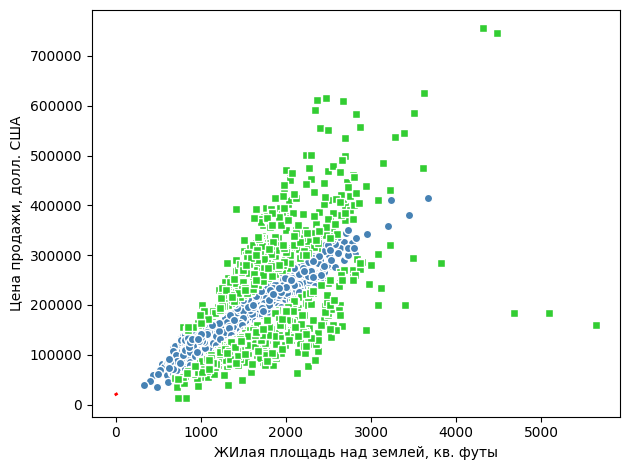

In [30]:
inlier_mask = ransac.inlier_mask_
outlier_mask = np.logical_not(inlier_mask)
line_x = np.arange(3, 10, 1)
line_y_ransac = ransac.predict(line_x[:, np.newaxis])
plt.scatter(X[inlier_mask], y[inlier_mask], c='steelblue', marker='o',
            label='inliers', edgecolor='white')
plt.scatter(X[outlier_mask], y[outlier_mask], c='limegreen', marker='s',
            label='outliers', edgecolor='white')
plt.plot(line_x, line_y_ransac, label='RANSAC', color='red', lw=2)
plt.xlabel('ЖИлая площадь над землей, кв. футы')
plt.ylabel('Цена продажи, долл. США')
plt.tight_layout()
plt.show()

In [33]:
from sklearn.model_selection import train_test_split
target = 'SalePrice'
features = df.columns[df.columns != target]
X = df[features].values
y = df[target].values
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=123, test_size=0.3)
slr = LinearRegression()
slr.fit(X_train, y_train)
y_train_pred = slr.predict(X_train)
y_test_pred = slr.predict(X_test)

In [34]:
from sklearn.metrics import mean_absolute_error
mae_train = mean_absolute_error(y_train, y_train_pred)
mae_test = mean_absolute_error(y_test, y_test_pred)
print(mae_train)
print(mae_test)

25983.026623990812
24921.288963945477


In [35]:
from sklearn.metrics import r2_score
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)
print(train_r2)
print(test_r2)

0.7694948430504934
0.7515748205718921


In [ ]:
from sklearn.linear_model import ElasticNet
elanet = ElasticNet(alpha=1., l1_ratio=0.5)